# Day 37 — Backpropagation & Optimisers
### Gradient Descent · Chain Rule · SGD vs Adam vs RMSprop · Learning Rate Scheduling

## 1. Setup & Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")

print(f"PyTorch:  {torch.__version__}")
print(f"CUDA:     {torch.cuda.is_available()}")

# load titanic
df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["FareLog"] = np.log1p(df["Fare"])
df["HasCabin"] = df["Cabin"].notna().astype(int)
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
title_map = {"Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master"}
df["Title"] = df["Title"].map(title_map).fillna("Other")
for t in ["Mr", "Mrs", "Miss", "Master"]:
    df[f"Title_{t}"] = (df["Title"] == t).astype(int)

features = [
    "Pclass",
    "Age",
    "FareLog",
    "FamilySize",
    "IsAlone",
    "HasCabin",
    "Sex_encoded",
    "Title_Mr",
    "Title_Mrs",
    "Title_Miss",
    "Title_Master",
]
X = df[features].values
y = df["Survived"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train)
y_test_t = torch.FloatTensor(y_test)

print(f"\nDataset: {df.shape}")
print(f"Train: {X_train_t.shape} | Test: {X_test_t.shape}")
print("Ready! ✅")

PyTorch:  2.12.0+cpu
CUDA:     False

Dataset: (891, 22)
Train: torch.Size([712, 11]) | Test: torch.Size([179, 11])
Ready! ✅


## 2. What is Backpropagation?

In [2]:
print("=" * 55)
print("       WHAT IS BACKPROPAGATION?")
print("=" * 55)
print("""
GOAL: Teach the network to reduce its mistakes.

THE PROBLEM:
  Network makes a prediction ŷ
  We compare ŷ to the true label y
  Loss = how wrong we were
  We need to know: which weights caused the error?

BACKPROPAGATION = Chain Rule of Calculus applied
to a neural network to compute:
  ∂Loss/∂w  for EVERY weight w in the network

INTUITION:
  Think of a mountain (loss surface).
  We are standing somewhere on it.
  Gradient tells us the slope at our current point.
  We step DOWNHILL (negative gradient direction)
  to find the lowest point (minimum loss).

THE 4 STEPS EVERY TRAINING ITERATION:
  1. FORWARD  → compute prediction ŷ
  2. LOSS     → measure error: L = BCELoss(ŷ, y)
  3. BACKWARD → compute gradients: ∂L/∂w
  4. UPDATE   → w = w - lr × ∂L/∂w

IN PYTORCH:
  optimizer.zero_grad()   ← clear old gradients
  loss.backward()         ← compute new gradients
  optimizer.step()        ← update all weights
""")

       WHAT IS BACKPROPAGATION?

GOAL: Teach the network to reduce its mistakes.

THE PROBLEM:
  Network makes a prediction ŷ
  We compare ŷ to the true label y
  Loss = how wrong we were
  We need to know: which weights caused the error?

BACKPROPAGATION = Chain Rule of Calculus applied
to a neural network to compute:
  ∂Loss/∂w  for EVERY weight w in the network

INTUITION:
  Think of a mountain (loss surface).
  We are standing somewhere on it.
  Gradient tells us the slope at our current point.
  We step DOWNHILL (negative gradient direction)
  to find the lowest point (minimum loss).

THE 4 STEPS EVERY TRAINING ITERATION:
  1. FORWARD  → compute prediction ŷ
  2. LOSS     → measure error: L = BCELoss(ŷ, y)
  3. BACKWARD → compute gradients: ∂L/∂w
  4. UPDATE   → w = w - lr × ∂L/∂w

IN PYTORCH:
  optimizer.zero_grad()   ← clear old gradients
  loss.backward()         ← compute new gradients
  optimizer.step()        ← update all weights



## 3. Gradients in Action

In [ ]:
print("=" * 55)
print("       GRADIENTS IN ACTION")
print("=" * 55)

# simple example — one weight, see gradient computed
x = torch.tensor([1.0, 2.0, 3.0])
w = torch.tensor([0.5, 0.5, 0.5], requires_grad=True)  # track gradients
y_true = torch.tensor(1.0)

# forward pass
y_pred = torch.sigmoid(torch.dot(w, x))
loss = -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))

print(f"Weights before:   {w.data}")
print(f"Prediction:       {y_pred.item():.4f}")
print(f"Loss:             {loss.item():.4f}")

# backward pass
loss.backward()

print(f"\nGradients ∂L/∂w:  {w.grad}")
print(f"\nMeaning:")
print(f"  w[0] gradient = {w.grad[0]:.4f} → adjust w[0] by this amount")
print(f"  w[1] gradient = {w.grad[1]:.4f} → adjust w[1] by this amount")
print(f"  w[2] gradient = {w.grad[2]:.4f} → adjust w[2] by this amount")

# manual weight update (what optimizer.step() does internally)
lr = 0.1
with torch.no_grad():
    w_new = w - lr * w.grad

print(f"\nWeights after 1 update (lr={lr}):")
print(f"  Before: {w.data}")
print(f"  After:  {w_new}")
print(f"\nLoss should decrease next forward pass ✅")

       GRADIENTS IN ACTION
Weights before:   tensor([0.5000, 0.5000, 0.5000])
Prediction:       0.9526
Loss:             0.0486

Gradients ∂L/∂w:  tensor([-0.0474, -0.0949, -0.1423])

Meaning:
  w[0] gradient = -0.0474 → adjust w[0] by this amount
  w[1] gradient = -0.0949 → adjust w[1] by this amount
  w[2] gradient = -0.1423 → adjust w[2] by this amount

Weights after 1 update (lr=0.1):
  Before: tensor([0.5000, 0.5000, 0.5000])
  After:  tensor([0.5047, 0.5095, 0.5142])

Loss should decrease next forward pass ✅


## 4. Optimisers — SGD vs Adam vs RMSprop

       COMPARING OPTIMISERS
SGD        → Final Loss: 0.4428 | Accuracy: 79.3%
Adam       → Final Loss: 0.4041 | Accuracy: 83.8%
RMSprop    → Final Loss: 0.3850 | Accuracy: 82.7%


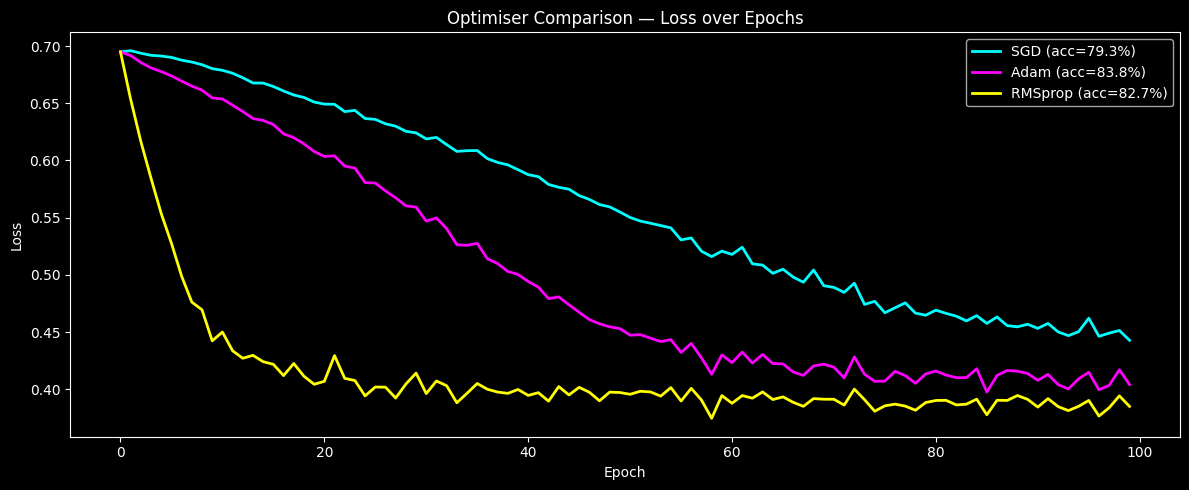

In [ ]:
print("=" * 55)
print("       COMPARING OPTIMISERS")
print("=" * 55)


class TitanicNet(nn.Module):
    def __init__(self):
        super(TitanicNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(11, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.network(x).squeeze()


def train_model(optimizer_name, epochs=100):
    torch.manual_seed(42)
    model = TitanicNet()
    criterion = nn.BCELoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)

    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train_t)
        loss = criterion(y_pred, y_train_t)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    # final accuracy
    model.eval()
    with torch.no_grad():
        y_pred_class = (model(X_test_t).numpy() >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred_class)
    return losses, acc


# train all 3
results = {}
for name in ["SGD", "Adam", "RMSprop"]:
    losses, acc = train_model(name)
    results[name] = {"losses": losses, "acc": acc}
    print(f"{name:10s} → Final Loss: {losses[-1]:.4f} | Accuracy: {acc*100:.1f}%")

# plot
fig, ax = plt.subplots(figsize=(12, 5))
colors = {"SGD": "cyan", "Adam": "magenta", "RMSprop": "yellow"}
for name, data in results.items():
    ax.plot(
        data["losses"],
        color=colors[name],
        label=f"{name} (acc={data['acc']*100:.1f}%)",
        linewidth=2,
    )

ax.set_title("Optimiser Comparison — Loss over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Learning Rate Scheduling

       LEARNING RATE SCHEDULING

PROBLEM WITH FIXED LEARNING RATE:
  Too high → overshoots minimum, loss bounces
  Too low  → learns too slowly, gets stuck

SOLUTION: Start high, reduce over time!
  Early epochs  → big steps (explore quickly)
  Later epochs  → small steps (fine-tune carefully)

Epoch  25 | Loss: 0.3863 | LR: 0.005000
Epoch  50 | Loss: 0.3843 | LR: 0.002500
Epoch  75 | Loss: 0.3681 | LR: 0.001250
Epoch 100 | Loss: 0.3690 | LR: 0.000625


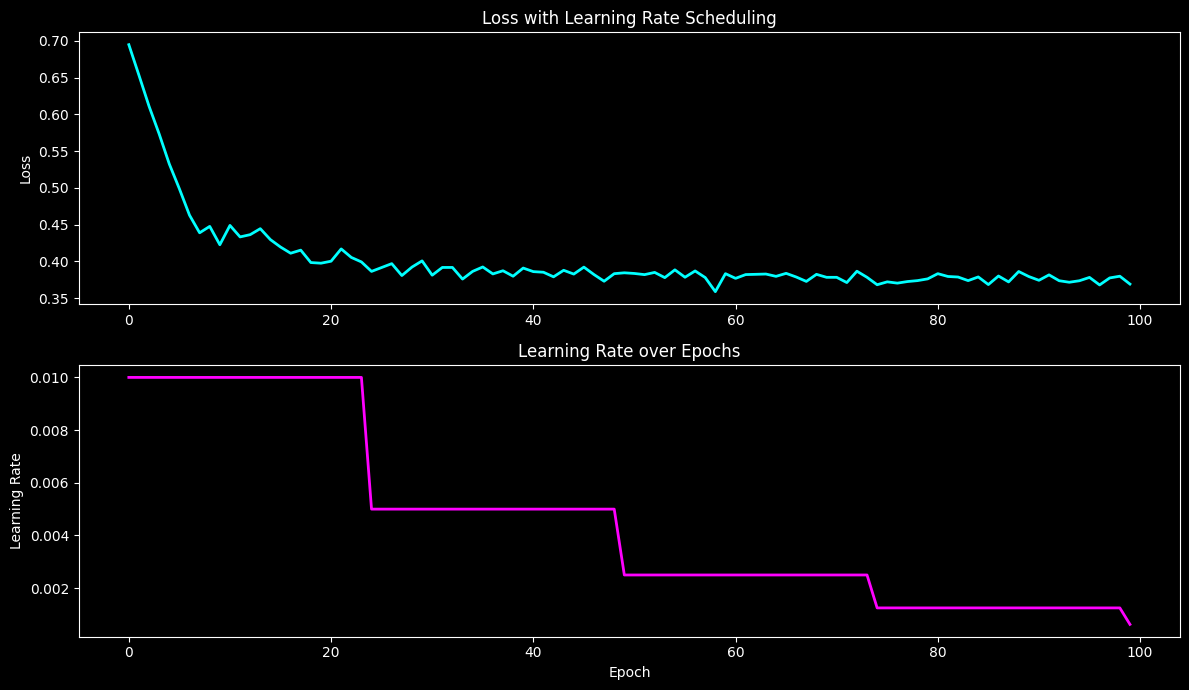

In [ ]:
print("=" * 55)
print("       LEARNING RATE SCHEDULING")
print("=" * 55)
print("""
PROBLEM WITH FIXED LEARNING RATE:
  Too high → overshoots minimum, loss bounces
  Too low  → learns too slowly, gets stuck

SOLUTION: Start high, reduce over time!
  Early epochs  → big steps (explore quickly)
  Later epochs  → small steps (fine-tune carefully)
""")

torch.manual_seed(42)
model = TitanicNet()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# StepLR — reduce lr by factor every N epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.5)
# every 25 epochs → lr = lr × 0.5

losses = []
lrs = []

for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    loss.backward()
    optimizer.step()
    scheduler.step()  # update learning rate

    losses.append(loss.item())
    lrs.append(optimizer.param_groups[0]["lr"])

    if (epoch + 1) % 25 == 0:
        print(
            f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}"
        )

# plot loss + lr together
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

ax1.plot(losses, color="cyan", linewidth=2)
ax1.set_title("Loss with Learning Rate Scheduling")
ax1.set_ylabel("Loss")

ax2.plot(lrs, color="magenta", linewidth=2)
ax2.set_title("Learning Rate over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Learning Rate")

plt.tight_layout()
plt.show()

## 6. Key Takeaways

In [6]:
print("=" * 55)
print("       DAY 37 — KEY TAKEAWAYS")
print("=" * 55)
print("""
BACKPROPAGATION:
  ✅ Chain rule applied to compute ∂Loss/∂w
  ✅ 4 steps: Forward → Loss → Backward → Update
  ✅ PyTorch automates this with autograd
  ✅ zero_grad() → backward() → step()

GRADIENTS:
  ✅ Gradient = slope of loss w.r.t. each weight
  ✅ Negative gradient → increase weight
  ✅ Positive gradient → decrease weight
  ✅ Magnitude = how much to adjust

OPTIMISERS COMPARED:
  ✅ SGD      → simple, slow, needs momentum
  ✅ Adam     → adaptive lr, best default (83.8%)
  ✅ RMSprop  → fast convergence, good for noisy data

LEARNING RATE SCHEDULING:
  ✅ StepLR   → halve lr every N epochs
  ✅ Start high → explore fast
  ✅ End low  → fine-tune carefully
  ✅ Improved final loss vs fixed lr

WHEN TO USE WHAT:
  Default choice → Adam lr=0.001
  Need fast convergence → RMSprop
  Simple baseline → SGD + momentum
  Always → add a scheduler for better results!
""")

       DAY 37 — KEY TAKEAWAYS

BACKPROPAGATION:
  ✅ Chain rule applied to compute ∂Loss/∂w
  ✅ 4 steps: Forward → Loss → Backward → Update
  ✅ PyTorch automates this with autograd
  ✅ zero_grad() → backward() → step()

GRADIENTS:
  ✅ Gradient = slope of loss w.r.t. each weight
  ✅ Negative gradient → increase weight
  ✅ Positive gradient → decrease weight
  ✅ Magnitude = how much to adjust

OPTIMISERS COMPARED:
  ✅ SGD      → simple, slow, needs momentum
  ✅ Adam     → adaptive lr, best default (83.8%)
  ✅ RMSprop  → fast convergence, good for noisy data

LEARNING RATE SCHEDULING:
  ✅ StepLR   → halve lr every N epochs
  ✅ Start high → explore fast
  ✅ End low  → fine-tune carefully
  ✅ Improved final loss vs fixed lr

WHEN TO USE WHAT:
  Default choice → Adam lr=0.001
  Need fast convergence → RMSprop
  Simple baseline → SGD + momentum
  Always → add a scheduler for better results!

